In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')


## Probit

indifference point instead of RNP

In [44]:
from stress_risk.behavior.utils import get_data
import bambi

df = get_data() 
df['x'] = df['log(risky/safe)']

formulae = 'chose_risky ~ x*session*group + (x*session|subject)'
model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels','bambi-RNP-fit_trace_model1.netcdf'))

from stress_risk.behavior.utils import extract_rnp_precision
intercept, gamma = extract_rnp_precision(idata, model, df, True) # important 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)
indif_point = 1/rnp



In [62]:
dd_i = (indif_point.xs(2,0,'session') - indif_point.xs(1,0,'session')).stack().stack()
dd_g = (gamma.xs(2,0,'session') - gamma.xs(1,0,'session')).stack().stack()

dd_i = dd_i.rename(mapper={'chose_risky_mean':'Indifference Point'}, axis=1)
dd_g = dd_g.rename(mapper={'chose_risky_mean':'Slope'}, axis=1)

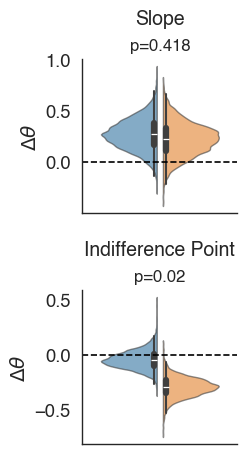

In [122]:
dd = pd.concat([dd_i, dd_g], axis=1)
difdif = dd.xs(1,0,'group') - dd.xs(0,0,'group')

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

params = ['Slope','Indifference Point']

fig, axs = plt.subplots(2,1, figsize=(2,5)) #

for ax, param in zip(axs, params):
    d = dd[param].to_frame()
    sns.violinplot(d.reset_index(),y=param, hue='group',split=True,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    ax.axhline(0, c='k', ls='--') 
    
    pval = np.round(np.mean(difdif[param]>0),3)
    ax.set(ylabel=r'$\Delta\theta$') # ylim=[ymin, new_ymax], 
    ax.set_title(f'p={pval}', fontsize=12)
    ax.annotate(f'{param}', xy=(0.5, 1), xytext=(0, 25), 
             xycoords='axes fraction', textcoords='offset points',
             size=14, ha='center', va='baseline',fontweight='bold')

sns.despine()
fig.subplots_adjust(hspace = 0.5) # adjust vertical space between axes
plt.savefig(op.join(plot_folder_path, f'probit-model_diffinsessions_violin_v2.pdf'), bbox_inches='tight')



## NLC

use model where priors shift together (model-label 5)

In [123]:
model_label = '5'
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

In [124]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df


def get_post_diffindiff(idata,param):
    df_control_dif = get_posterior(idata,param,'session')
    df_stress_dif = get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
    df_c = pd.concat((df_control_dif, df_stress_dif), axis=0)
    df_c = df_c.set_index('regressor', append=True)
    return df_c

In [125]:
df_prior = get_post_diffindiff(idata,'prior_mu')
df_1e = get_post_diffindiff(idata,'n1_evidence_sd')
df_2e = get_post_diffindiff(idata,'n2_evidence_sd')

dd = pd.concat([df_prior,df_1e,df_2e], axis=1)
dd = dd.stack().to_frame('value')
dd.index = dd.index.set_names(['chain','draw','regressor','param'])
dd.index = dd.index.set_levels(['Control', 'Stress'], level='regressor')

df_prior = get_posterior(idata,'prior_mu','session:group').drop('regressor', axis=1)
df_1e = get_posterior(idata,'n1_evidence_sd','session:group').drop('regressor', axis=1)
df_2e = get_posterior(idata,'n2_evidence_sd','session:group').drop('regressor', axis=1)

dd_difdif = pd.concat([df_prior, df_1e,df_2e], axis=1)

In [138]:
dd_difdif.head()

prior_mu_mu  n1_evidence_sd_mu  n2_evidence_sd_mu
chain draw                                                   
0     0        0.399449           0.115272          -0.072114
      1        0.215092           0.021398          -0.038387
      2        0.160996           0.062958          -0.066947
      3        0.291055           0.015416           0.042929
      4        0.289602           0.182993           0.004358

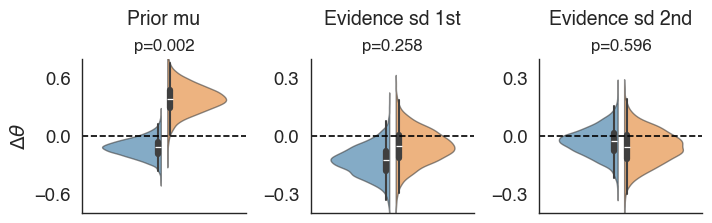

In [141]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

params = dd.index.get_level_values('param').unique()
col_names = ['Prior mu','Evidence sd 1st','Evidence sd 2nd']
y_range_scaler = 0.95
fig, axs = plt.subplots(1,len(params), figsize=(8,2)) #2.5, 1

for ax, param,col_name in zip(axs, params,col_names):
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='value', hue='regressor',split=True,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    p_val = np.round(np.mean(dd_difdif[param]<0),3)
    ax.axhline(0, c='k', ls='--')
    ymin, ymax = ax.get_ylim()
    ax.set(ylim=[-.4,.4], ylabel=None,xlabel=None, yticks=[-.3,0,.3]) #[-ymax*y_range_scaler, ymax*y_range_scaler]
    #ax.set_title(f'p = {p_val}', fontsize=12)

    ax.set_title(f'p={p_val}', fontsize=12)
    ax.annotate(f'{col_name}', xy=(0.5, 1), xytext=(0, 25), 
             xycoords='axes fraction', textcoords='offset points',
             size=14, ha='center', va='baseline',fontweight='bold')
sns.despine()
axs[0].set(ylabel=r'$\Delta\theta$',ylim=[-.8,.8],yticks=[-.6,0,.6] )
fig.subplots_adjust(wspace = 0.4) # adjust horizontal space between axes
plt.savefig(op.join(plot_folder_path, f'NLC-{model_label}-post_stres-control_violin.pdf'), bbox_inches='tight')